In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv('D:\DEV VELLY\Datasets\Salary Data.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HASEEB\AppData\Local\Temp\ipykernel_17892\2767996547.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('D:\DEV VELLY\Datasets\Salary Data.csv')


In [3]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(50)

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [7]:
df["Age"]

0      32.0
1      28.0
2      45.0
3      36.0
4      52.0
       ... 
370    35.0
371    43.0
372    29.0
373    34.0
374    44.0
Name: Age, Length: 375, dtype: float64

In [8]:
df.isnull().sum()

Age                    0
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [9]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [10]:
df['Gender']

0        Male
1      Female
2        Male
3      Female
4        Male
        ...  
370    Female
371      Male
372    Female
373      Male
374    Female
Name: Gender, Length: 375, dtype: str

In [11]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [12]:
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].mode()[0])

In [13]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [14]:
df['Job Title'] = df['Job Title'].fillna(df['Job Title'].mode()[0])

In [15]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    2
Salary                 2
dtype: int64

In [16]:
df['Years of Experience'] = df['Years of Experience'].fillna(df['Years of Experience'].mean())

In [17]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 2
dtype: int64

In [18]:
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [19]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(50)

In [21]:
df.drop_duplicates(inplace = True)

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.shape

(325, 6)

<Axes: >

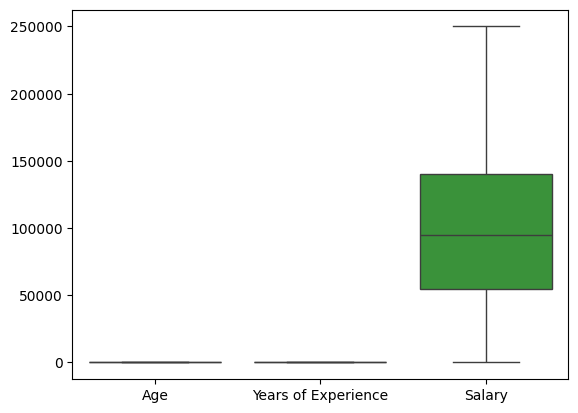

In [24]:
sns.boxplot(df)

In [25]:
from sklearn.preprocessing import LabelEncoder
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

C:\Users\HASEEB\AppData\Local\Temp\ipykernel_17892\411928747.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [26]:
X = df.drop('Years of Experience', axis = 1)
y = df['Years of Experience']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state= 42)

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
lr  = LinearRegression()
lr.fit(X_train, y_train)

print('Train Score : ', lr.score(X_train, y_train))
print('Test Score : ', lr.score(X_test, y_test))

Train Score :  0.9617404060090817
Test Score :  0.9685772462392421


<Axes: xlabel='Years of Experience', ylabel='Count'>

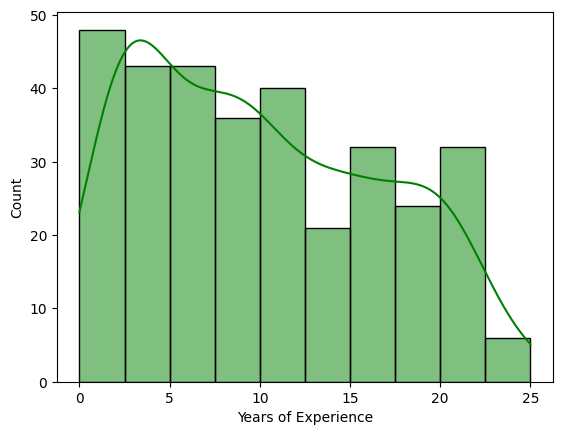

In [29]:
sns.histplot(df['Years of Experience'], kde = True, color = 'green')

In [30]:
df.describe()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
count,325.000000,325.000000,325.000000,325.000000,325.000000,325.000000
mean,37.382867,0.526154,0.538462,88.772308,10.058556,99970.307692
std,7.174747,0.500085,0.713125,47.151422,6.640199,48577.919969
min,23.000000,0.000000,0.000000,0.000000,0.000000,350.000000
25%,31.000000,0.000000,0.000000,49.000000,4.000000,55000.000000
50%,37.000000,1.000000,0.000000,91.000000,9.000000,95000.000000
75%,44.000000,1.000000,1.000000,132.000000,16.000000,140000.000000
max,53.000000,1.000000,2.000000,173.000000,25.000000,250000.000000


In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 325 entries, 0 to 371
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  325 non-null    float64
 1   Gender               325 non-null    int64  
 2   Education Level      325 non-null    int64  
 3   Job Title            325 non-null    int64  
 4   Years of Experience  325 non-null    float64
 5   Salary               325 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 17.8 KB


In [32]:
ridge = Ridge(alpha = 10)
ridge.fit(X_train, y_train)
print('Train Score : ', ridge.score(X_train, y_train))
print('Train Score : ', ridge.score(X_test, y_test))

Train Score :  0.9581745923938445
Train Score :  0.9703602241843454


In [33]:
lasso = Lasso(alpha = 0.1)
lasso.fit(X_train, y_train)

print('Train Score : ', lasso.score(X_train, y_train))
print('Train Score : ', lasso.score(X_test, y_test))

Train Score :  0.9608792665148288
Train Score :  0.9684042250911734


In [34]:
coef_df = pd.DataFrame({
    "Feature" : X.columns,
    "Linear" : lr.coef_,
    "Ridge" : ridge.coef_,
    "Lasso " : lasso.coef_
})

coef_df.set_index("Feature", inplace = True)
coef_df

,Linear,Ridge,Lasso
Feature,,,
Age,5.815194,4.823752,5.667821
Gender,0.139996,0.056108,0.026362
Education Level,0.278449,0.166455,0.191398
Job Title,-0.116205,-0.104296,-0.000000
Salary,0.513301,1.436135,0.601776


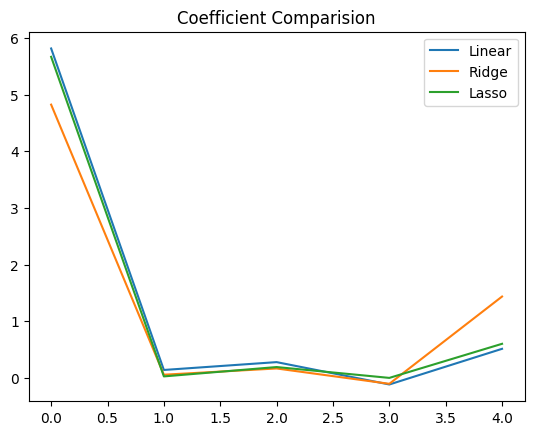

In [35]:
plt.figure()
plt.plot(lr.coef_, label = 'Linear')
plt.plot(ridge.coef_, label = 'Ridge')
plt.plot(lasso.coef_, label = 'Lasso')
plt.legend()

plt.title('Coefficient Comparision')
plt.show()